In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import requests
import io

print("Environment ready!")
print (f"pandas version: {pd.__version__}")

Environment ready!
pandas version: 3.0.1


In [2]:
url = "https://raw.githubusercontent.com/ccodwg/CovidTimelineCanada/main/data/other/fluwatch/fluwatch.csv"

response = requests.get(url)
print(f"Status: {response.status_code}") # a 200 code = success

#Loading into pandas
df = pd.read_csv(io.StringIO(response.text
                             ))

print(f"\nShape: {df.shape[0]} rows * {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
df.head()

Status: 404

Shape: 0 rows * 1 columns

Columns: ['404: Not Found']


,404: Not Found


In [ ]:
#importing available data from PHAC FluWatch

import time

# base URL pattern for PHAC FluWatch historical CSVs
base_url = "https://health.canada.ca/apps/open-data/fluwatch/FluWatch{}RespiratoryVirusDetectionsIsolations-en.csv"

# seasons tried
seasons = [
           "2014-2015", "2015-2016", "2016-2017", "2017-2018", 
           "2018-2019", "2019-2020", "2020-2021", "2021-2022",
           "2022-2023", "2023-2024"
           ]

frames = []

for season in seasons:
    url = base_url.format(season)
    response = requests.get(url)

    if response.status_code == 200:
        df_season = pd.read_csv(io.StringIO(response.text)) # converts the strings into a format pandas can read as a "file"
        df_season['season'] = season  # tag each row with its season
        frames.append(df_season)
        print(f"+ {season} - {len(df_season)} rows")
    else:
        print(f"x {season} - not available (404)") #error handling to prevent a crush

    time.sleep(0.5) # 'being polite to the server'. This is to prevent the server from blocking my request thinking I am a bot.

# Combining everything to one DataFrame
if frames:
    df_historical = pd.concat(frames, ignore_index=True) #stacks up the seasons on top of each other from 0,1,2,3... and so on
    print(f"\nTotal rows combined: {len(df_historical)}")
    print(f"Columns: {list(df_historical.columns)}")
    df_historical.head()






+ 2014-2015 - 56 rows
+ 2015-2016 - 55 rows
+ 2016-2017 - 55 rows
x 2017-2018 - not available (404)
x 2018-2019 - not available (404)
x 2019-2020 - not available (404)
x 2020-2021 - not available (404)
x 2021-2022 - not available (404)
x 2022-2023 - not available (404)
x 2023-2024 - not available (404)

Total rows combined: 166
Columns: ['InfluenzaSeasonandEpidemiologicalWeek', 'TotalFluTests', 'PositiveFluAH1N1pdm09', 'PositiveFluAH3', 'PositiveFluAunsubtyped', 'TotalFluBPositive', 'TotalRSVTests', 'TotalPositiveRSV', 'TotalParaTests', 'TotalPositivePara', 'TotalAdenoTests', 'TotalPositiveAdeno', 'TotalhMPVTests', 'TotalPositivehMPV', 'TotalEnteroRhinoTests', 'TotalPositiveEnteroRhino', 'TotalCoronaTests', 'TotalPositiveCorona', 'season']


In [4]:
# checks the structure of the data
print(df_historical.head(10).to_string())

  InfluenzaSeasonandEpidemiologicalWeek  TotalFluTests  PositiveFluAH1N1pdm09  PositiveFluAH3  PositiveFluAunsubtyped  TotalFluBPositive  TotalRSVTests  TotalPositiveRSV  TotalParaTests  TotalPositivePara  TotalAdenoTests  TotalPositiveAdeno  TotalhMPVTests  TotalPositivehMPV  TotalEnteroRhinoTests  TotalPositiveEnteroRhino  TotalCoronaTests  TotalPositiveCorona     season
0                                201435         1311.0                    0.0             0.0                     2.0                3.0         1327.0               5.0          1160.0               23.0           1169.0                16.0          1026.0                1.0                  595.0                     154.0            1140.0                  2.0  2014-2015
1                                201436         1323.0                    0.0             1.0                     2.0                1.0         1334.0               3.0          1155.0               27.0           1164.0                20.0       

In [ ]:
# Step 1 - Creating a total influenza positive column (sum of all flu subtypes: AH1N1 +AH3 +unsubtyped + FluB)

df_historical['TotalFluPositive'] = (
    df_historical['PositiveFluAH1N1pdm09'] +
    df_historical['PositiveFluAH3'] +
    df_historical['PositiveFluAunsubtyped'] +
    df_historical['TotalFluBPositive']
)

# Step 2 - Decode the Epidemiological Week as it is a combination of year + week. Turning into a real date.
df_historical['year'] = df_historical['InfluenzaSeasonandEpidemiologicalWeek'].astype(str).str[:4].astype(int) # slices up to the 4th position char
df_historical['week'] = df_historical['InfluenzaSeasonandEpidemiologicalWeek'].astype(str).str[4:].astype(int) # slices everything after the 4th position char

# converting year + week number into a real datetime
df_historical['date'] = pd.to_datetime(
    df_historical['year'].astype(str) + '-W' +
    df_historical['week'].astype(str).str.zfill(2) + '-1',
    format='%Y-W%W-%w'
)

#Step 3 - sorting it chronologically
df_historical = df_historical.sort_values('date').reset_index(drop=True)

#Step 4 - confirmation (error handling)
print(df_historical[['date', 'season', 'TotalFluPositive']].head(10))
print(f"\nData range: {df_historical['date'].min().date()} to {df_historical['date'].max().date()}")
print(f"Total Weeks: {len(df_historical)}")

ValueError: invalid literal for int() with base 10: 'Sour'

In [ ]:
# Step 1 — total influenza positives column
df_historical['TotalFluPositive'] = (
    df_historical['PositiveFluAH1N1pdm09'] +
    df_historical['PositiveFluAH3'] +
    df_historical['PositiveFluAunsubtyped'] +
    df_historical['TotalFluBPositive']
)


# Checking for any non-numeric values that could cause errors
col = df_historical['InfluenzaSeasonandEpidemiologicalWeek'].astype(str)
print("Sample values:", col.head(5).tolist())
print("Any non-numeric?", col[~col.str.isnumeric()].unique())

# The output indicates that there embedded citations and methodology notes at the bottom of the CSV files.
# Extremely common in government data.

Sample values: ['201435', '201436', '201437', '201438', '201439']
Any non-numeric? <StringArray>
[                                                                                    'Source: Influenza and Respiratory Infectious Diseases Database System (IRIDDS) (accessed January 2018), FluWatch Program, Public Health Agency of Canada. ',
 'Data were provided by 32 sentinel laboratories (Newfoundland (1), Prince Edward Island (1), Nova Scotia (1), New Brunswick (1), Quebec (6), Ontario (17), Manitoba (1), Saskatchewan (2), Alberta (1), and British Columbia (1)) participating',
                                                                                                                                                                       'in the FluWatch Respiratory Virus Detection Surveillance System (RVDSS).']
Length: 3, dtype: str


In [ ]:
# Step 1 - Creating a total influenza positive column (sum of all flu subtypes: AH1N1 +AH3 +unsubtyped + FluB)

df_historical['TotalFluPositive'] = (
    df_historical['PositiveFluAH1N1pdm09'] +
    df_historical['PositiveFluAH3'] +
    df_historical['PositiveFluAunsubtyped'] +
    df_historical['TotalFluBPositive']
)

# Step 2 - Removing and footnote rows before decoding the dates. Only numeric rows where the week column is purely numeric is retained.
col = df_historical['InfluenzaSeasonandEpidemiologicalWeek'].astype(str)
df_historical = df_historical[col.str.isnumeric()].copy() # Boolean indexing - only True values (purely numeric values) are copied to df_historical

print(f"Rows after removing footnotes: {len(df_historical)}")


#Step 3 - Safe decoding of year and week
df_historical['year'] = df_historical['InfluenzaSeasonandEpidemiologicalWeek'].astype(str).str[:4].astype(int)
df_historical['week'] = df_historical['InfluenzaSeasonandEpidemiologicalWeek'].astype(str).str[4:].astype(int)

# Step 4 - converting into a real datetime
df_historical['date'] = pd.to_datetime(
    df_historical['year'].astype(str) + '-W' +
    df_historical['week'].astype(str).str.zfill(2) + '-1',
    format='%Y-W%W-%w'
)

#Step 5 - Sorting chronologically
df_historical = df_historical.sort_values('date').reset_index(drop=True)

#Step 6 - Confirmation (error handling)
print(df_historical[['date', 'season', 'TotalFluPositive']].head(10))
print(f"\nData range: {df_historical['date'].min().date()} to {df_historical['date'].max().date()}")
print(f"Total Weeks: {len(df_historical)}")


#The output shows that cases start low in Septmber and steadily climb through October and November as winter approaches. This is a raw pattern.

Rows after removing footnotes: 157
        date     season  TotalFluPositive
0 2014-09-01  2014-2015               5.0
1 2014-09-08  2014-2015               4.0
2 2014-09-15  2014-2015              15.0
3 2014-09-22  2014-2015              19.0
4 2014-09-29  2014-2015              26.0
5 2014-10-06  2014-2015              31.0
6 2014-10-13  2014-2015              39.0
7 2014-10-20  2014-2015              52.0
8 2014-10-27  2014-2015              51.0
9 2014-11-03  2014-2015              60.0

Data range: 2014-09-01 to 2017-08-21
Total Weeks: 157


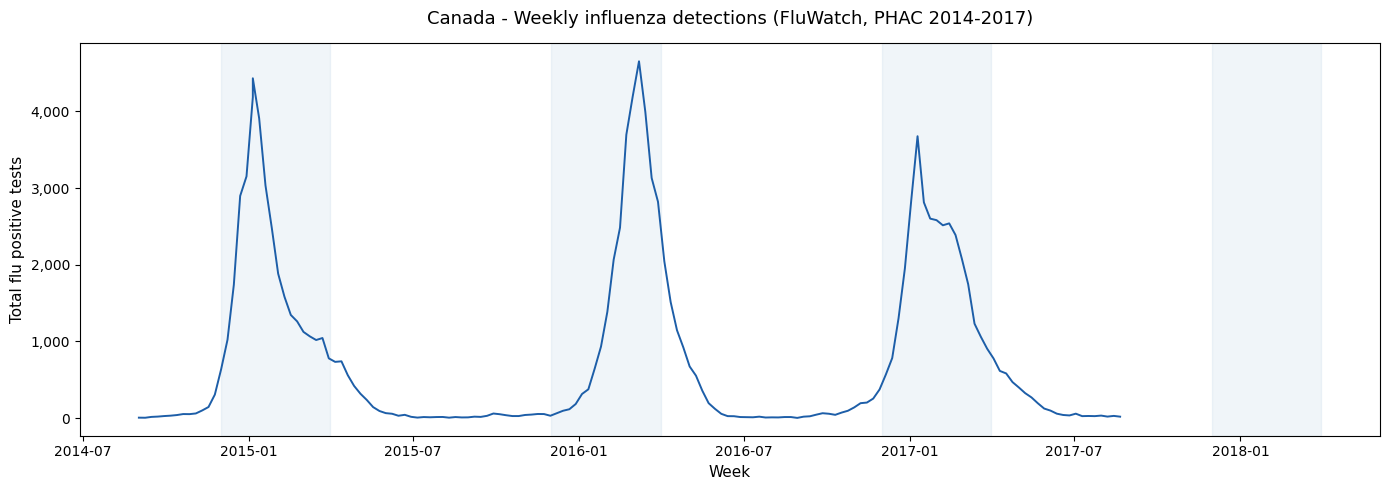

Chart saved to data/sprint1_national.png


In [ ]:
# Plotting
fig, ax = plt.subplots(figsize=(14, 5))

# Plotting the flu positive counts over time
ax.plot(df_historical['date'], df_historical['TotalFluPositive'],
        color = '#1D5EA8', linewidth = 1.4)

# To make the seasonal pattern obvious, the peak winter months (December to March) will be shaded
for year in range(2014, 2018):
    ax.axvspan(
        pd.Timestamp(f'{year}-12-01'),
        pd.Timestamp(f'{year+1}-03-31'),
        alpha=0.08, color = 'steelblue', label = '_nolegend_'
    )

# Labels and formatting
ax.set_xlabel('Week', fontsize = 11)
ax.set_ylabel('Total flu positive tests', fontsize = 11)
ax.set_title('Canada - Weekly influenza detections (FluWatch, PHAC 2014-2017)',
             fontsize = 13, pad = 14)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

plt.tight_layout() #ensure nothing is cut off
plt.savefig('../data/sprint1_national.png', dpi = 150, bbox_inches = 'tight') # dpi - dots per inch. Controls the image resolution for viewing.
plt.show()

print("Chart saved to data/sprint1_national.png")


Reflection questions
1. What is the seasonal pattern? When does flu peak and when does it disappear?
The shaded regions which mark the peak winter seasons (December - March) are consistent with peak flu cases while the unshaded parts indicate the warmer seasons with infections almost zero.

2. What differs between the three peak seasons that i can see?
The peak season of 2015-2016 had the highest positive test result, with numbers close to 4600 followed by the 2014-2015 season with numbers close to 4400.
The winter season of 2016-2017 is peculiar in the sense that it has two different peaks, indicating that two different strains were in season. However, one was prevalent over the other.
The summer/warmer seasons over the 2014 - 2018 were consistenly low in terms of low positive results.

3. What does the near-zero summer baseline mean for a forecasting model?
This serves as the model's indicator of 'low activity' and any increase or upward deviation from this state should send AfyaBora into alert mode as an outbreak is in season.

4. What does this data NOT show that I'd want to know in order to build a better model?
It could show the weeks a bit better. Probably in terms of which months. The graph could potentially be interactive, to allow for easier interpretations of the weeks and the number of results.

Also, if there would more than one strains in season, the model should be able to track them individually and then display them.
For a draft (v 0.1) model, it isn't that bad really.

5. How does what I have plotted connect to what AB is trying to collect? 
It introduces the data pipeline that AB will be working with. The key fundamentals in terms of acquiring, loading, cleaning and plotting data are being set allowing for scalability in the future where larger, messier datasets will be used.

In [12]:
# Saving cleaned data for direct loading by Sprint 2

df_historical.to_csv('../data/fluwatch_clean.csv', index = False)
print("Saved to data/fluwatch_clean.csv")

Saved to data/fluwatch_clean.csv
